# Clasificación de Sistema Operativo mediante Regresión Logística

## Objetivo

El objetivo de esta actividad es desarrollar un modelo de Machine Learning que permita predecir qué sistema operativo utiliza un usuario (Windows, Macintosh o Linux) a partir de características de navegación obtenidas de un sitio web.

La variable objetivo es:

- 0: Windows
- 1: Macintosh
- 2: Linux

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("usuarios_win_mac_lin.csv")

df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


**Exploracion de los datos**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duracion  170 non-null    float64
 1   paginas   170 non-null    int64  
 2   acciones  170 non-null    int64  
 3   valor     170 non-null    int64  
 4   clase     170 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 6.8 KB


In [4]:
df.describe()

,duracion,paginas,acciones,valor,clase
count,170.000000,170.000000,170.000000,170.000000,170.000000
mean,111.075729,2.041176,8.723529,32.676471,0.752941
std,202.453200,1.500911,9.136054,44.751993,0.841327
min,1.000000,1.000000,1.000000,1.000000,0.000000
25%,11.000000,1.000000,3.000000,8.000000,0.000000
50%,13.000000,2.000000,6.000000,20.000000,0.000000
75%,108.000000,2.000000,10.000000,36.000000,2.000000
max,898.000000,9.000000,63.000000,378.000000,2.000000


In [5]:
df.isnull().sum()

duracion    0
paginas     0
acciones    0
valor       0
clase       0
dtype: int64



En esta etapa se realizó una inspección inicial del conjunto de datos para verificar su estructura, los tipos de variables y la existencia de valores faltantes.

Se observó que el dataset cuenta con 170 registros y 5 variables. Las variables predictoras son duración, páginas vistas, acciones y valor de las acciones, mientras que la variable objetivo es "clase", que representa el sistema operativo utilizado por el usuario.

No se encontraron valores nulos, por lo que no fue necesario realizar tareas de limpieza de datos.

In [6]:
df['clase'].value_counts()

clase
0    86
2    44
1    40
Name: count, dtype: int64

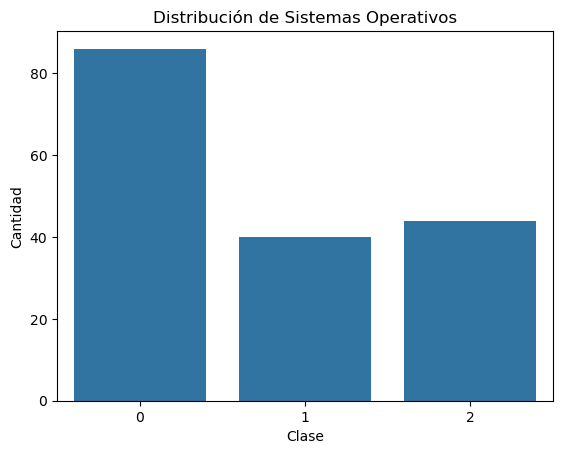

In [7]:
sns.countplot(data=df, x='clase')
plt.title("Distribución de Sistemas Operativos")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

## Interpretación de la distribución de clases

Al analizar la variable objetivo se observa que la clase 0 (Windows) es la más frecuente, con 86 registros. Por otro lado, las clases 1 (Macintosh) y 2 (Linux) presentan 40 y 44 registros respectivamente.

Si bien existe una mayor cantidad de usuarios Windows, la diferencia no es excesiva, por lo que el conjunto de datos mantiene una distribución relativamente equilibrada para entrenar un modelo de clasificación.

**Separación de variables**

In [8]:
X = df[['duracion', 'paginas', 'acciones', 'valor']]
y = df['clase']

**Division entrenamiento y prueba**

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Entrenamiento**

In [12]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)

modelo.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


**Predicciones**

In [14]:
y_pred = modelo.predict(X_test)

print(y_pred[:10])

[0 1 2 1 0 0 0 0 0 2]


**Accuracy**

In [16]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6764705882352942


## Evaluación del modelo

El modelo obtuvo una precisión (Accuracy) de aproximadamente 67,65%, lo que significa que logró clasificar correctamente cerca de dos tercios de los usuarios del conjunto de prueba.

Este resultado indica que la Regresión Logística puede identificar patrones en los datos de navegación para predecir el sistema operativo utilizado, aunque todavía existen casos en los que las clases son confundidas entre sí.

Considerando que se trata de un problema de clasificación con tres categorías distintas (Windows, Macintosh y Linux), el desempeño obtenido puede considerarse aceptable para este conjunto de datos.

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.81      0.70        16
           1       0.67      0.33      0.44        12
           2       0.86      1.00      0.92         6

    accuracy                           0.68        34
   macro avg       0.71      0.72      0.69        34
weighted avg       0.68      0.68      0.65        34




El reporte de clasificación permite evaluar el desempeño del modelo para cada una de las clases.

La clase 2 (Linux) obtuvo los mejores resultados, alcanzando un recall de 1.00 y un F1-score de 0.92, lo que indica que todos los casos reales de esta categoría fueron identificados correctamente.

La clase 0 (Windows) presentó un desempeño aceptable, con un recall de 0.81 y un F1-score de 0.70.

La clase 1 (Macintosh) fue la más difícil de clasificar, obteniendo un recall de 0.33, lo que sugiere que algunos registros de esta categoría fueron confundidos con otras clases.

En términos generales, el modelo alcanzó una precisión global (Accuracy) cercana al 68%, mostrando una capacidad razonable para clasificar el sistema operativo de los usuarios a partir de las variables analizadas.

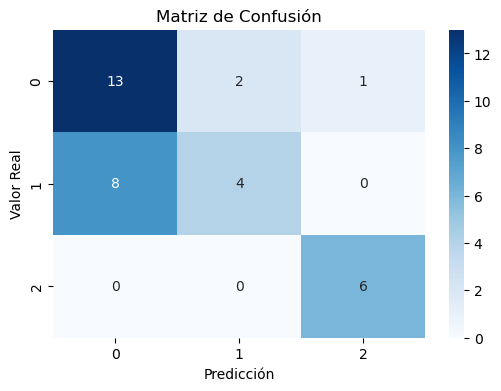

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

matriz = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

La matriz de confusión permite visualizar las predicciones correctas e incorrectas realizadas por el modelo.

Se observa que:

- De los 16 usuarios Windows, 13 fueron clasificados correctamente.
- De los 12 usuarios Macintosh, solamente 4 fueron identificados correctamente, mientras que varios fueron confundidos con Windows.
- Los 6 usuarios Linux fueron clasificados correctamente.

Estos resultados muestran que el modelo logra distinguir muy bien a los usuarios Linux y presenta un desempeño aceptable para Windows. Sin embargo, encuentra mayores dificultades para diferenciar a los usuarios Macintosh, lo que afecta la precisión general del modelo.

# Conclusiones

En esta actividad se desarrolló un modelo de Regresión Logística para predecir el sistema operativo utilizado por un usuario a partir de características de navegación web.

Durante el proceso se realizó la exploración del conjunto de datos, la preparación de las variables, el entrenamiento del modelo y su posterior evaluación mediante métricas de clasificación.

El modelo alcanzó una precisión aproximada del 68%, logrando buenos resultados especialmente en la clasificación de usuarios Linux y Windows. La clase Macintosh presentó una mayor dificultad de clasificación, lo que evidencia oportunidades de mejora en el modelo o en la cantidad de datos disponibles.

Esta práctica permitió aplicar conceptos de aprendizaje supervisado y comprender cómo utilizar algoritmos de clasificación para resolver problemas reales mediante Machine Learning.